# Interpretación del Modelo - Diabetes

### By:
Maria Camila Aristizábal Aguirre

### Date:
2026-08-20

## 📚 Import  libraries

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import learning_curve

## 💾 Load data

In [2]:
MODELS_DIR = Path("../../data/06_models")
modelo_rf = joblib.load(MODELS_DIR / "modelo_final_random_forest.joblib")

MODEL_INPUT_DIR = Path("../../data/05_model_input")
train = pd.read_parquet(MODEL_INPUT_DIR / "train.parquet")
test = pd.read_parquet(MODEL_INPUT_DIR / "test.parquet")

COLUMNAS_FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
TARGET = "Outcome"

X_train, y_train = train[COLUMNAS_FEATURES], train[TARGET].astype(bool)
X_test, y_test = test[COLUMNAS_FEATURES], test[TARGET].astype(bool)

print(f"Modelo cargado: {modelo_rf}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Modelo cargado: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10, n_estimators=200,
                                        random_state=42))])
Train: (629, 8) | Test: (158, 8)


## 🌳 Feature Importance (MDI)

Se extrae la importancia de cada variable según la disminución media de
impureza (Mean Decrease in Impurity) acumulada en los árboles del Random
Forest, junto con la desviación estándar entre árboles individuales (mide
qué tan consistente es esa importancia a través del ensamble).

**Limitación conocida de MDI**: tiende a sobreestimar la importancia de
variables continuas o con muchos valores únicos (como `Glucose` o `BMI`)
frente a variables más discretas (como `Pregnancies`), por la forma en que
se construyen los splits. Por eso se complementa más abajo con permutation
importance, que no tiene este sesgo.

In [ ]:
modelo_interno = modelo_rf.named_steps["model"]

importancias_mdi = modelo_interno.feature_importances_
std_mdi = np.std([arbol.feature_importances_ for arbol in modelo_interno.estimators_], axis=0)

tabla_importancia_mdi = pd.DataFrame(
    {"importancia": importancias_mdi, "std": std_mdi}, index=COLUMNAS_FEATURES
).sort_values("importancia", ascending=False)

tabla_importancia_mdi

,importancia,std
Glucose,0.309350,0.171432
BMI,0.218515,0.137901
Age,0.166551,0.125274
Insulin,0.085127,0.093767
DiabetesPedigreeFunction,0.072468,0.056632
SkinThickness,0.069543,0.083442
Pregnancies,0.056282,0.066261
BloodPressure,0.022163,0.024059


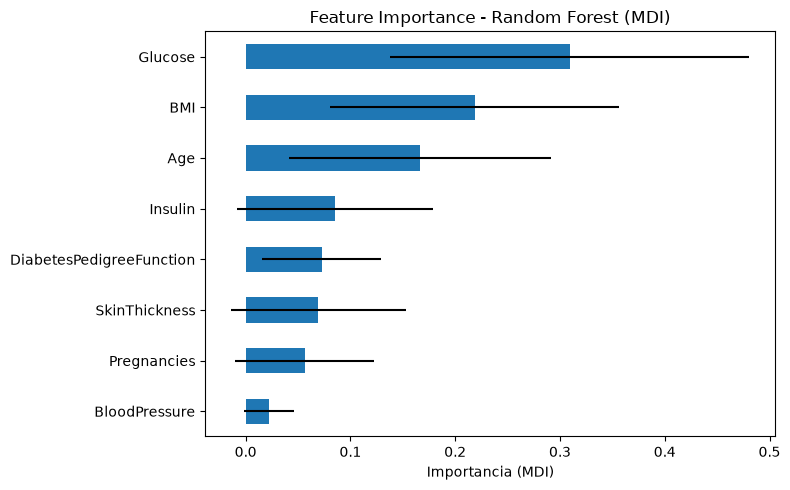

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
tabla_importancia_mdi.sort_values("importancia").plot.barh(
    y="importancia", xerr="std", ax=ax, legend=False, color="tab:blue"
)
ax.set_xlabel("Importancia (MDI)")
ax.set_title("Feature Importance - Random Forest (MDI)")
plt.tight_layout()
plt.savefig(
    "../../data/08_reporting/interpretacion_feature_importance_mdi.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 🔀 Permutation Importance (conjunto de test)

A diferencia de MDI (calculado sobre train, con sesgo hacia variables
continuas), permutation importance mide cuánto empeora el F1 del modelo
cuando se baraja aleatoriamente cada variable en el conjunto de **test**,
rompiendo su relación con el objetivo. Es agnóstico al tipo de modelo y no
tiene el sesgo de MDI, por lo que sirve como validación cruzada del
hallazgo anterior.

In [5]:
resultado_permutacion = permutation_importance(
    modelo_rf, X_test, y_test, n_repeats=30, random_state=42, scoring="f1"
)

tabla_permutation = pd.DataFrame(
    {
        "importancia_media": resultado_permutacion.importances_mean,
        "std": resultado_permutacion.importances_std,
    },
    index=COLUMNAS_FEATURES,
).sort_values("importancia_media", ascending=False)

tabla_permutation

,importancia_media,std
Glucose,0.129524,0.042520
BMI,0.025678,0.032737
Age,0.019103,0.025913
Insulin,0.002230,0.025873
Pregnancies,-0.000810,0.011909
SkinThickness,-0.005517,0.021128
DiabetesPedigreeFunction,-0.007857,0.016276
BloodPressure,-0.019523,0.008223


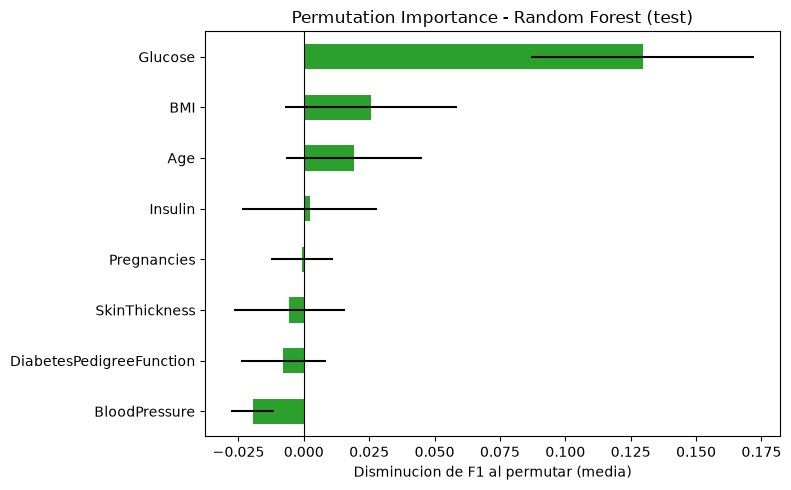

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
tabla_permutation.sort_values("importancia_media").plot.barh(
    y="importancia_media", xerr="std", ax=ax, legend=False, color="tab:green"
)
ax.set_xlabel("Disminucion de F1 al permutar (media)")
ax.set_title("Permutation Importance - Random Forest (test)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(
    "../../data/08_reporting/interpretacion_permutation_importance.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 📈 Learning Curve y escalabilidad (Random Forest)

Se reutiliza la metodología de la Tarea 6, ahora enfocada únicamente en el
modelo seleccionado (Random Forest), para completar el requisito del
issue #19.

In [9]:
train_sizes_abs, train_scores, val_scores, fit_times, score_times = learning_curve(
    modelo_rf,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="f1",
    return_times=True,
    random_state=42,
)

val_media = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
fit_times_media = fit_times.mean(axis=1)
fit_times_std = fit_times.std(axis=1)

print("Tamaños de entrenamiento evaluados:", train_sizes_abs)
print("F1 validacion (media):", np.round(val_media, 3))
print("Tiempo de ajuste (media, s):", np.round(fit_times_media, 4))

Tamaños de entrenamiento evaluados: [ 50 100 150 201 251 301 352 402 452 503]
F1 validacion (media): [0.624 0.637 0.657 0.659 0.69  0.687 0.699 0.702 0.702 0.704]
Tiempo de ajuste (media, s): [0.1196 0.1171 0.1226 0.1244 0.1297 0.1326 0.137  0.1388 0.1423 0.1461]


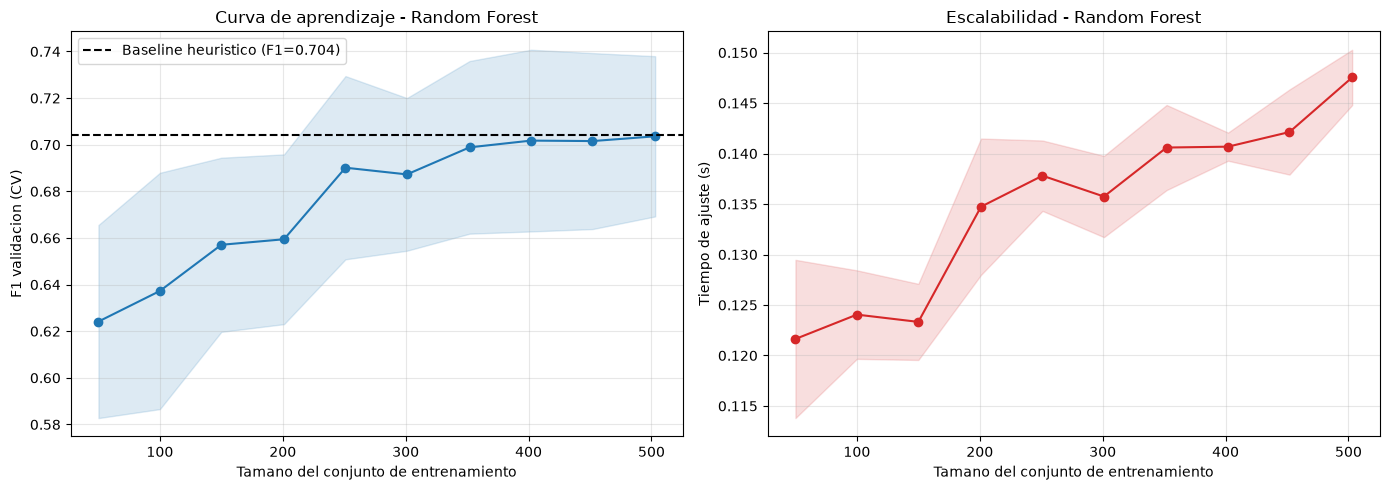

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_sizes_abs, val_media, "o-", color="tab:blue")
axes[0].fill_between(
    train_sizes_abs,
    val_media - val_std,
    val_media + val_std,
    alpha=0.15,
    color="tab:blue",
)
axes[0].axhline(0.704, color="black", linestyle="--", label="Baseline heuristico (F1=0.704)")
axes[0].set_xlabel("Tamano del conjunto de entrenamiento")
axes[0].set_ylabel("F1 validacion (CV)")
axes[0].set_title("Curva de aprendizaje - Random Forest")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_sizes_abs, fit_times_media, "o-", color="tab:red")
axes[1].fill_between(
    train_sizes_abs,
    fit_times_media - fit_times_std,
    fit_times_media + fit_times_std,
    alpha=0.15,
    color="tab:red",
)
axes[1].set_xlabel("Tamano del conjunto de entrenamiento")
axes[1].set_ylabel("Tiempo de ajuste (s)")
axes[1].set_title("Escalabilidad - Random Forest")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../../data/08_reporting/interpretacion_learning_curve.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 🔍 Matriz de confusión (test, umbral=0.436)

Se reutiliza el umbral óptimo encontrado en la Tarea 6 (ajustado vía
`cross_val_predict` sobre train, sin fuga de información) para clasificar
el conjunto de test y analizar los tipos de error del modelo.

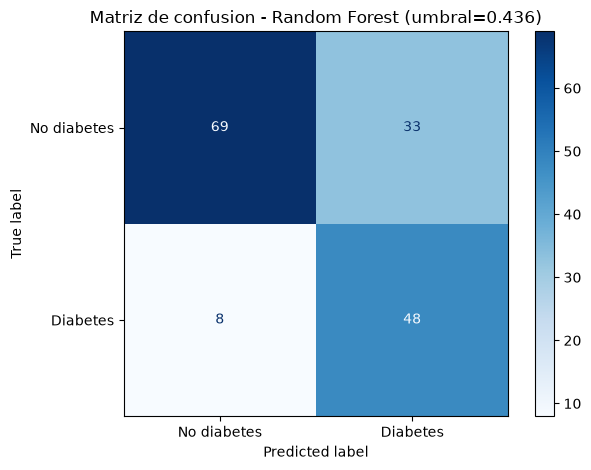

Verdaderos negativos: 69
Falsos positivos: 33
Falsos negativos: 8
Verdaderos positivos: 48


In [10]:
UMBRAL_OPTIMO = 0.436

proba_test = modelo_rf.predict_proba(X_test)[:, 1]
y_pred_test = (proba_test >= UMBRAL_OPTIMO).astype(int)

matriz = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(matriz, display_labels=["No diabetes", "Diabetes"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusion - Random Forest (umbral={UMBRAL_OPTIMO})")
plt.tight_layout()
plt.savefig(
    "../../data/08_reporting/interpretacion_matriz_confusion.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

vn, fp, fn, vp = matriz.ravel()
print(f"Verdaderos negativos: {vn}")
print(f"Falsos positivos: {fp}")
print(f"Falsos negativos: {fn}")
print(f"Verdaderos positivos: {vp}")

### Consecuencias de las malas predicciones

De 158 pacientes en test, el modelo comete 41 errores (33 falsos positivos +
8 falsos negativos), con recall=0.857 y precision=0.593.

**Falsos negativos (8 casos, 14.3% de los diabéticos reales):** el modelo
predice "no diabetes" en un paciente que sí la tiene. Es el error más costoso
clínicamente — implica diagnóstico tardío, ausencia de tratamiento oportuno y
riesgo de complicaciones (daño renal, cardiovascular, neuropatía) que
podrían prevenirse con detección temprana.

**Falsos positivos (33 casos, 32.4% de los pacientes sanos):** el modelo
predice "diabetes" en un paciente sano. El costo es menor pero no nulo:
exámenes de seguimiento innecesarios, ansiedad del paciente, y gasto en el
sistema de salud.

**Esta asimetría de costos justifica la elección del umbral (0.436, por
debajo de 0.5):** al bajar el umbral de decisión, el modelo se vuelve más
"alarmista" — clasifica como diabetes con menos evidencia, lo que reduce
falsos negativos (el error grave) a costa de más falsos positivos (el error
más tolerable). Con un umbral de 0.5 por defecto, el recall sería menor y se
perderían más casos reales de diabetes.

In [ ]:
X_test_analisis = X_test.copy()
X_test_analisis["Outcome_real"] = y_test.to_numpy()
X_test_analisis["Outcome_predicho"] = y_pred_test.astype(bool)
X_test_analisis["proba_diabetes"] = proba_test

falsos_negativos = X_test_analisis[
    (X_test_analisis["Outcome_real"]) & (~X_test_analisis["Outcome_predicho"])
]
falsos_positivos = X_test_analisis[
    (~X_test_analisis["Outcome_real"]) & (X_test_analisis["Outcome_predicho"])
]

print(f"--- Falsos negativos ({len(falsos_negativos)} casos) ---")
print(falsos_negativos[[*COLUMNAS_FEATURES, "proba_diabetes"]].to_string())
print("\n--- Estadisticas de test completo (referencia) ---")
print(X_test[COLUMNAS_FEATURES].describe())

--- Falsos negativos (8 casos) ---
     Pregnancies  Glucose  BloodPressure  SkinThickness   Insulin   BMI  DiabetesPedigreeFunction   Age  proba_diabetes
23           2.0    155.0           74.0           17.0  4.574711  26.6                  0.359770  27.0        0.303652
56           8.0    120.0           86.0           30.0  4.852030  28.4                  0.230318  22.0        0.392720
61           2.0     93.0           64.0           32.0  5.081404  38.0                  0.515216  23.0        0.289491
64           3.0    139.0           54.0           30.0  4.852030  25.6                  0.337900  22.0        0.207927
65          12.0     92.0           62.0            7.0  5.556828  27.6                  0.655445  44.0        0.392945
81           0.0    119.0           72.0           30.0  4.852030  32.4                  0.131905  24.0        0.342915
107          1.0     95.0           82.0           25.0  5.198497  35.0                  0.209450  43.0        0.348738
152  

In [ ]:
mediana_insulin_train = X_train["Insulin"].median()
print(f"Valor mediana de Insulin (train, log-transformado): {mediana_insulin_train:.6f}")

n_fn_imputados = (falsos_negativos["Insulin"] == mediana_insulin_train).sum()
n_fp_imputados = (falsos_positivos["Insulin"] == mediana_insulin_train).sum()

print(
    f"Falsos negativos con Insulin imputado (mediana): {n_fn_imputados} de {len(falsos_negativos)}"
)
print(
    f"Falsos positivos con Insulin imputado (mediana): {n_fp_imputados} de {len(falsos_positivos)}"
)
print(
    f"Proporcion de Insulin imputado en test completo: {(X_test['Insulin'] == mediana_insulin_train).mean():.3f}"
)

print(f"\n--- Falsos positivos ({len(falsos_positivos)} casos) — estadisticas ---")
print(falsos_positivos[[*COLUMNAS_FEATURES, "proba_diabetes"]].describe())

Valor mediana de Insulin (train, log-transformado): 4.852030
Falsos negativos con Insulin imputado (mediana): 4 de 8
Falsos positivos con Insulin imputado (mediana): 21 de 33
Proporcion de Insulin imputado en test completo: 0.487

--- Falsos positivos (33 casos) — estadisticas ---
       Pregnancies     Glucose  BloodPressure  SkinThickness    Insulin  \
count    33.000000   33.000000      33.000000      33.000000  33.000000   
mean      4.575758  126.575758      76.878788      31.090909   4.939460   
std       2.704514   19.896655      14.679402       8.163806   0.292254   
min       0.000000  102.000000      48.000000      15.000000   4.219508   
25%       3.000000  110.000000      68.000000      30.000000   4.852030   
50%       4.000000  123.000000      80.000000      30.000000   4.852030   
75%       6.000000  136.000000      86.000000      32.000000   4.912655   
max      13.000000  189.000000     110.000000      54.000000   5.998937   

             BMI  DiabetesPedigreeFunction

### ¿Qué tipo de errores comete el modelo y a qué se deben?

**Insulin imputado (dato faltante, Tarea 4):** en los falsos negativos, el
50% (4/8) tiene Insulin imputado con la mediana — prácticamente igual a la
proporción del conjunto de test completo (48.7%), así que **no hay evidencia
de que la imputación explique los falsos negativos**. En los falsos
positivos, en cambio, el 63.6% (21/33) tiene Insulin imputado, ~15 puntos
por encima del 48.7% base — una asociación moderada, no concluyente con
n=33, pero que vale la pena investigar en una futura iteración (por ejemplo,
con `KNNImputer` o agregando un indicador binario de "valor era faltante").

**Clase desbalanceada (65/35):** se compensó con `class_weight="balanced"` y
con un umbral de decisión más bajo (0.436) para priorizar recall. Un efecto
colateral esperado de esa decisión es más falsos positivos — el modelo se
volvió deliberadamente "alarmista".

**Outliers:** no se observan valores extremos o atípicos en ninguno de los
41 casos mal clasificados — todos caen dentro de rangos plausibles del
dataset. Se descarta como causa principal de los errores.

**Encoders:** no aplica — el dataset es completamente numérico, sin
variables categóricas.

**Solapamiento natural de clases (hallazgo adicional):** el 100% de los
falsos positivos tiene Glucose ≥ 102 (mediana 123, muy cerca del umbral del
heurístico de 127) y BMI alto (mediana 32.5, mínimo 26) — es decir, tienen
exactamente el perfil de riesgo típico de un diabético, pero no lo eran al
momento de la medición. Esto no es un error corregible por mejor modelado:
refleja que los factores de riesgo son probabilísticos, no determinísticos.

**Falsos negativos con Glucose "normal":** 3 de los 8 falsos negativos
(93, 92, 95 mg/dL) tienen Glucose por debajo del percentil 25 del dataset
(<99), un rango clínicamente considerado normal. Son pacientes con
diagnóstico real de diabetes cuya lectura de glucosa en este snapshot no
reflejaba su condición — probable variabilidad biológica natural o momento
de medición no representativo, más que un fallo del modelo.

## Hallazgos - Interpretación del Modelo

### Interpretación general
Random Forest confirma, con evidencia propia e independiente del heurístico
de la Tarea 5, que **Glucose es la variable dominante**: lidera tanto en
MDI (0.309) como en permutation importance (0.130) — y es la única cuyo
intervalo de confianza en permutation importance nunca cruza cero. Esto
valida retroactivamente la elección del heurístico de usar únicamente
Glucose como regla de decisión.

**BMI y Age** muestran importancia positiva en ambos métodos, pero en
permutation importance sus intervalos de confianza cruzan cero — señal
débil, no robusta de forma individual, aunque plausible como factor
secundario.

**Insulin, Pregnancies, SkinThickness, DiabetesPedigreeFunction y
BloodPressure** tienen importancia negativa o cercana a cero en
permutation importance, a pesar de valores no triviales en MDI — evidencia
de que MDI sobreestima la relevancia real de estas variables continuas.

### Learning Curve y escalabilidad
Random Forest sigue mejorando con más datos de entrenamiento (F1 de
validación: 0.624→0.704), sin señales de plateau ni con el 100% de los
datos disponibles — sugiere que el techo de desempeño actual (empate
técnico con el baseline) es una limitación del tamaño del dataset, no del
modelo. El tiempo de ajuste crece de forma lineal con los datos
(0.12s→0.146s), un costo computacional bajo incluso a mayor escala.

### Consecuencias de las malas predicciones
8 falsos negativos (diagnóstico tardío, el error clínicamente más grave) y
33 falsos positivos (exámenes de seguimiento innecesarios, menos grave).
El umbral de decisión (0.436, por debajo de 0.5) se eligió deliberadamente
para priorizar recall sobre precision, dada esta asimetría de costos.

### Causas de los errores
No se identifican outliers extremos ni aplica el uso de encoders (dataset
numérico). La imputación de Insulin (dato faltante) no está asociada a los
falsos negativos (50% vs. 48.7% base), pero sí moderadamente a los falsos
positivos (63.6% vs. 48.7% base). El desbalance de clases se compensó con
`class_weight="balanced"` y el ajuste de umbral. Se identifica además un
solapamiento natural entre clases: los falsos positivos tienen
sistemáticamente el perfil de riesgo típico (Glucose≥102, BMI alto) sin
haber desarrollado diabetes — un límite inherente del problema, no un
defecto del modelo o los datos.

### Listado de pruebas y experimentos para la siguiente iteración
1. Probar `KNNImputer` o agregar un indicador binario de "valor faltante"
   para Insulin, dado su asociación con los falsos positivos.
2. Recolectar más datos de entrenamiento: la Learning Curve de Random
   Forest no muestra plateau, sugiriendo margen real de mejora.
3. Explorar variables derivadas (interacción Glucose×BMI, Glucose×Age),
   ya que BMI y Age muestran señal individual débil pero podrían aportar
   en combinación.
4. Evaluar calibración de probabilidades (`CalibratedClassifierCV`), dado
   el desbalance de clases y el ajuste manual de umbral.
5. Explorar un enfoque híbrido (heurístico + Random Forest como respaldo
   en casos de probabilidad intermedia) en vez de elegir un único modelo.

## 💾 Modelo entrenado

Se reutiliza el modelo `.joblib` guardado en la Tarea 6
(`data/06_models/modelo_final_random_forest.joblib`), sin reentrenar, para
mantener un único modelo de referencia consistente entre ambas tareas.